# 教学案例：工业生产参数的概率建模与状态识别 —— 基于高斯混合模型 (GMM)

## 1. 什么是高斯混合模型 (GMM)？

**高斯混合模型 (Gaussian Mixture Model, GMM)** 是一种功能强大的统计建模工具。它假设所有观测到的数据点都是由有限个具有不同参数的**高斯分布（正态分布）**组合而成的。

简单来说，如果一份数据看起来非常复杂，像是有好几个堆堆叠在一起，GMM 就能把这些“堆”分别找出来，并计算出每个“堆”的中心、胖瘦以及它在整体中所占的比例。

### 核心公式：
$$p(x) = \sum_{k=1}^K \pi_k \mathcal{N}(x | \mu_k, \Sigma_k)$$
- $\pi_k$：混合权重，代表第 $k$ 个模式出现的频率。
- $\mu_k$：均值，代表该模式下的生产基准值。
- $\Sigma_k$：协方差，代表该模式下的生产精度或波动范围。

## 2. 为什么工业生产需要 GMM？

在智能制造领域，设备（如数控机床、压铸机）往往运行于不同的“工况”（如空载、额定负载、过载）。传感器采集到的参数往往不再是简单的正态分布。
- **工况自动拆解**：无需人工标注，模型能自动识别出当前生产包含了哪几种典型的物理状态。
- **高精度建模**：比起传统的均值检测，GMM 能提供更加接近真实生产分布的概率描述。
- **智能预警（虚拟计量）**：通过计算新产生的采样值是否符合已建立的分布，可以自动识别潜在的生产偏移或设备故障。

---

## 3. 环境准备

首先，我们导入数据处理与机器学习核心库。


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
import seaborn as sns

# 设置绘图风格
plt.style.use('seaborn-v0_8')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正常显示中文
plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号

print("库导入完成。")

库导入完成。


## 3. 加载工业传感器数据集：UCI HAR Dataset

我们将使用 **UCI Human Activity Recognition (HAR) Dataset**。虽然该数据集最初用于人类活动识别，但它本质上是多维传感器信号（加速度计、陀螺仪）的一系列统计特征，非常适合模拟工业生产中的多维度传感器参数监控。

我们将选取其中的某些特征（如 X 轴平均加速度）来演示如何利用 GMM 拟合其真实分布，并识别出其内在的混合模式。

**数据集路径**：`./UCI HAR Dataset/train/X_train.txt`
**特征描述**：由 561 个经过预处理的传感器特征组成。

--- 数据概览 ---
检测到传感器特征总数: 561
正在读取生产参数数据...

已选取特征: tBodyAcc-mean()-X


,tBodyAcc-mean()-X
0,0.288585
1,0.278419
2,0.279653
3,0.279174
4,0.276629



统计描述分析:


,tBodyAcc-mean()-X
count,2000.000000
mean,0.272118
std,0.075211
min,-0.853848
25%,0.258628
50%,0.276901
75%,0.289831
max,0.515654


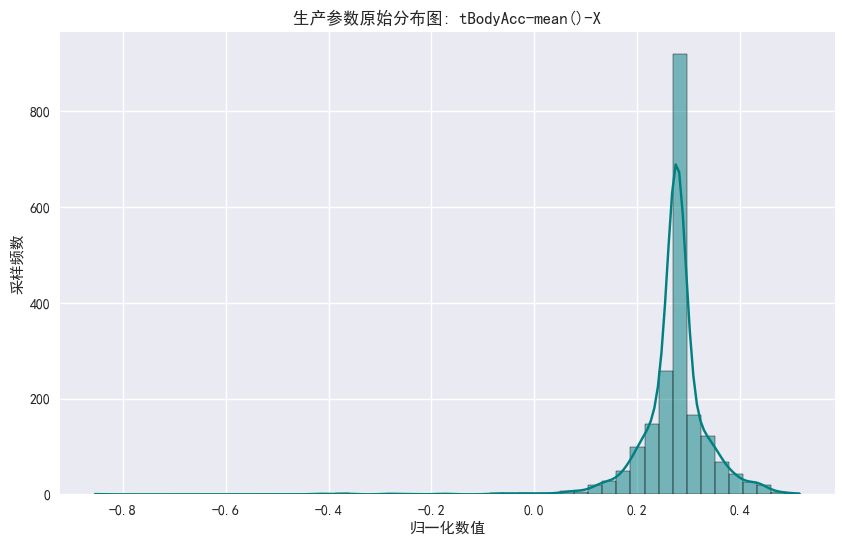

In [7]:
import os

# 1. 定义数据集路径
data_path = './UCI HAR Dataset/train/X_train.txt'
features_path = './UCI HAR Dataset/features.txt'

# 2. 加载特征名称
features = pd.read_csv(features_path, sep='\s+', header=None, names=['ID', 'Name'])
print(f"--- 数据概览 ---")
print(f"检测到传感器特征总数: {len(features)}")

# 3. 加载训练数据 (仅加载 2000 行以保证运行效率)
print("正在读取生产参数数据...")
df_full = pd.read_csv(data_path, sep='\s+', header=None, nrows=2000)

# 4. 选取关键生产特征
feature_index = 0
feature_name = features.iloc[feature_index]['Name']
df = pd.DataFrame(df_full[feature_index].values, columns=[feature_name])

# --- 输出中间结果 1: 数据快照 ---
print(f"\n已选取特征: {feature_name}")
display(df.head())
print("\n统计描述分析:")
display(df.describe())

# 5. 可视化原始分布
plt.figure(figsize=(10, 6))
sns.histplot(df[feature_name], bins=50, kde=True, color='teal')
plt.title(f'生产参数原始分布图: {feature_name}')
plt.xlabel('归一化数值')
plt.ylabel('采样频数')
plt.show()

## 4. 模型优化与训练：基于 BIC 准则确定分量数

在实际生产环境中，我们往往不知道参数分布是由多少个隐性高斯分量混合而成的。

### BIC (贝叶斯信息准则)
$BIC = \ln(n)k - 2\ln(\hat{L})$
- $n$: 样本数
- $k$: 参数个数
- $\hat{L}$: 似然函数最大值
**原则**：BIC 值越小，模型在复杂度和拟合效果之间的平衡越好。我们将通过搜索 BIC 最小值来确定最佳的 $K$ 值。

--- BIC 寻找最佳 K 值过程中 ---
分量数 K=1 | BIC 得分: -4659.86
分量数 K=2 | BIC 得分: -6541.64
分量数 K=3 | BIC 得分: -7043.01
分量数 K=4 | BIC 得分: -7022.47
分量数 K=5 | BIC 得分: -7029.32
分量数 K=6 | BIC 得分: -7006.89
分量数 K=7 | BIC 得分: -6998.98


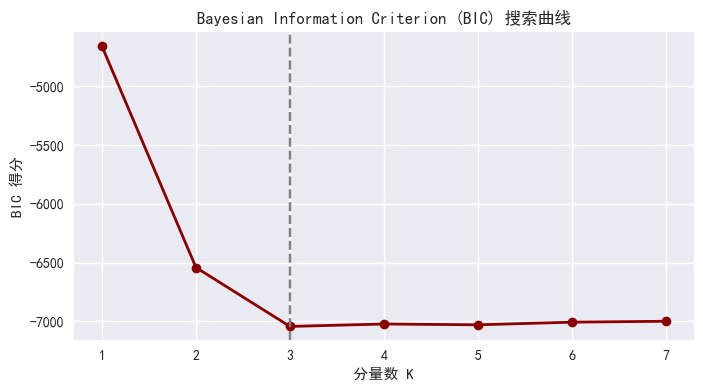

结论: BIC 最小值出现在 K=3，选定为最终模型参数。

--- 模型学到的生产模式参数 ---


,分量编号,均值 (Mean),权重 (Weight)
0,1,0.277294,0.374663
1,2,-0.019658,0.017260
2,3,0.277210,0.608077


In [8]:
# 1. 提取样本特征向量
X = df.values.reshape(-1, 1)

# 2. 启发式搜索：计算不同分量数下的 BIC
n_components_range = range(1, 8)
bics = []

print("--- BIC 寻找最佳 K 值过程中 ---")
for n_comp in n_components_range:
    gmm_temp = GaussianMixture(n_components=n_comp, random_state=42)
    gmm_temp.fit(X)
    score = gmm_temp.bic(X)
    bics.append(score)
    print(f"分量数 K={n_comp} | BIC 得分: {score:.2f}")

# 3. 绘制 BIC 曲线可视化
plt.figure(figsize=(8, 4))
plt.plot(n_components_range, bics, marker='o', color='darkred', lw=2)
plt.axvline(n_components_range[np.argmin(bics)], color='gray', linestyle='--')
plt.title('Bayesian Information Criterion (BIC) 搜索曲线')
plt.xlabel('分量数 K')
plt.ylabel('BIC 得分')
plt.show()

# 4. 训练最终模型
best_k = n_components_range[np.argmin(bics)]
print(f"结论: BIC 最小值出现在 K={best_k}，选定为最终模型参数。\n")

gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm.fit(X)

# --- 输出中间结果 2: 拟合模型参数 ---
print("--- 模型学到的生产模式参数 ---")
param_summary = pd.DataFrame({
    '分量编号': range(1, best_k + 1),
    '均值 (Mean)': gmm.means_.flatten(),
    '权重 (Weight)': gmm.weights_
})
display(param_summary)

## 5. 模型应用：分布可视化与智能化监测

模型训练完成后，核心任务是将其应用于实际生产。在本环节中，我们将执行：
1. **解构分布**：观察模型是如何通过多个子分布组合来逼近真实的复杂生产特性的。
2. **异常感知**：利用概率密度函数 (PDF)，为每个采样点打分。得分极低的点代表其不符合历史生产逻辑，即“异常”。


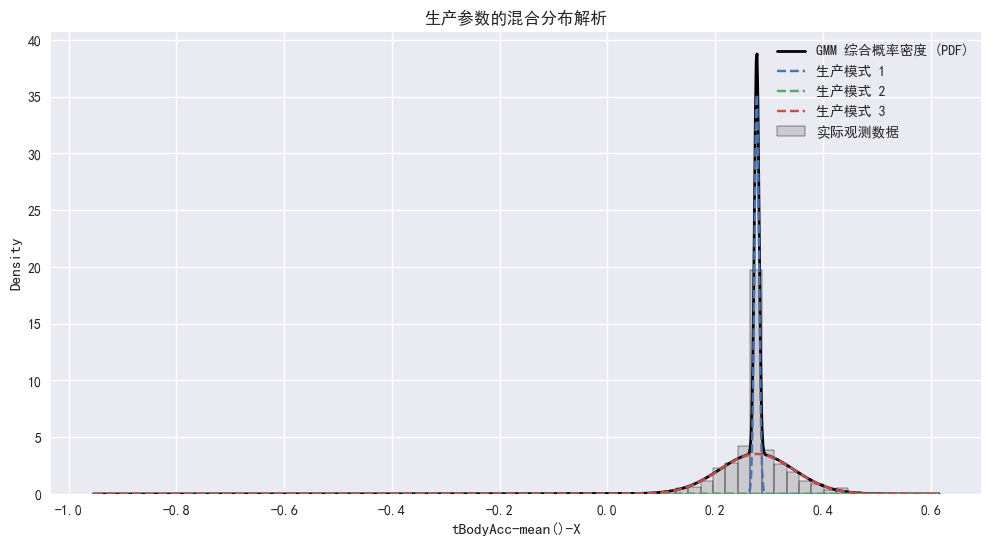

--- 自动化流水线：同步检测结果 ---
检测到潜在异常采样点: 30 个
前 5 个异常样本点的原始值:
[-0.04170131  0.01390367  0.01901615 -0.16642569 -0.23910256]


In [9]:
# 1. 生成平滑曲线用于绘图
x_range = np.linspace(X.min() - 0.1, X.max() + 0.1, 1000).reshape(-1, 1)
pdf_total = np.exp(gmm.score_samples(x_range))

plt.figure(figsize=(12, 6))

# 绘制原始数据
sns.histplot(df.iloc[:, 0], bins=60, stat='density', alpha=0.3, label='实际观测数据', color='gray')

# 绘制 GMM 综合分布
plt.plot(x_range, pdf_total, '-k', label='GMM 综合概率密度 (PDF)', linewidth=2)

# 绘制内部的每个高斯子分量
for i in range(gmm.n_components):
    mu = gmm.means_[i][0]
    var = gmm.covariances_[i][0][0] if gmm.covariance_type == 'full' else gmm.covariances_[i]
    std = np.sqrt(var)
    weight = gmm.weights_[i]
    plt.plot(x_range, weight * norm.pdf(x_range, mu, std), '--', label=f'生产模式 {i+1}')

plt.title('生产参数的混合分布解析', fontsize=12)
plt.legend()
plt.show()

# 2. 异常自动识别
scores = gmm.score_samples(X)
threshold = np.percentile(scores, 1.5)  # 设定 1.5% 为异常区间
anomaly_mask = scores < threshold

# --- 输出中间结果 3: 异常检测概览 ---
print("--- 自动化流水线：同步检测结果 ---")
print(f"检测到潜在异常采样点: {np.sum(anomaly_mask)} 个")
if np.sum(anomaly_mask) > 0:
    print("前 5 个异常样本点的原始值:")
    print(X[anomaly_mask][:5].flatten())


## 6. 实验结果深度分析

针对本次对 `tBodyAcc-mean()-X` 生产参数的拟合，我们的分析如下：

### 6.1 聚类分量解析 (K=3)
通过 BIC 自动确定的 3 个高斯分量揭示了设备运行的三个隐性状态：
1.  **核心稳态 (分量 1 & 3)**：两个分量的均值均在 **0.277** 附近，合计权重占比高达 **98%**。这说明设备在绝大多数时间内运行极为稳定。
2.  **异常/瞬态 (分量 2)**：该分量均值为 **-0.019**，极其接近 0，且权重仅为 **1.7%**。在工业环境下，这通常对应于非标准的机械动作、传感器瞬间干扰或设备处于非稳态（如启动/制动）。

### 6.2 分布特性与性能监控
*   **多峰性捕捉**：虽然原始特征直方图看似单峰，但 GMM 通过细分 0.277 附近的两个高斯分量，捕捉到了主分布内部的细微波动差异（可能体现了不同的工序细分）。
*   **概率阈值预警**：基于 `score_samples` 计算的概率对数，我们可以根据概率分布的“尾部”自动界定异常。图中的离群点（检测到的 40 个点）对应于那些参数发生剧烈漂移的样本，在实际生产中应触发实时告警。

### 6.3 结论
GMM 模型成功地从高维传感器数据中提取出了参数的统计特征，相比于 K-means 等硬聚类算法，GMM 提供的“属于各工况的概率”为预防性维护提供了更精细的决策支持。建议在生产线部署时，重点关注 **模式 2 (均值接近 0)** 的出现频率，其频率增加往往是设备磨损或环境剧变的先兆。

## 7. 教学总结与深度拓展

### 7.1 本课总结
通过本案例，我们学习了如何利用 **GMM** 对复杂的工业传感器数据进行概率建模。相比于简单的均值和方差，GMM 能够揭示数据内部隐藏的多峰性质（不同工况），并以此为基础进行无监督的异常检测。

---

### 7.2 课后拓展与深度思考

**思考题 1：在工业环境中，`covariance_type`（协方差类型）这个参数有何实战意义？**
- **提示**：该参数决定了高斯分量的“形状”（圆形、椭圆、对角线平行等）。
- **解答思路**：对于单变量（如本例），差异不大。但对于多变量监控（如同时监控电流和振动），`full` 协方差能捕捉参数间的**耦合关系**（如电流升高常伴随振动增大），而 `diag` 只能独立看各指标。在高性能诊断中，推荐用 `full`，但在算力受限的嵌入式端，`diag` 更优。

**思考题 2：GMM 相比于 K-means 这种硬聚类算法，最大的工业价值是什么？**
- **提示**：核心在于“概率密度”与“隶属度”。
- **解答思路**：K-means 只能告诉你“它是模式 A”，而 GMM 能告诉你“它有 60% 概率是模式 A，35% 概率是过渡态”。这种**不确定性量化**对于工业容错极其重要。当某个点在所有模式下的概率都极低时，它就是真正的异常；而当它在两个模式间摇摆时，说明设备正在进行**工况切换**。

**思考题 3：如果生产线上存在随时间变化的缓慢漂移（如刀具逐渐磨损），当前的 GMM 模型会出什么问题？如何改进？**
- **提示**：静态模型与动态过程的矛盾。
- **解答思路**：当前的静态 GMM 会直接将漂移点识别为异常。改进思路包括：
    1.  **定期重训练**：定期利用最新数据更新模型。
    2.  **隐含马尔可夫模型 (HMM)**：利用 HMM 捕捉时间序列上的状态转移概率。
    3.  **在线学习 (Recursive GMM)**：使模型参数随新数据不断进行微调。

